## Imports e configuração

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

%matplotlib inline

BASE_DIR      = Path("..")
PATH_IMAGES   = BASE_DIR / "data" / "raw" / "BBBC020_v1_images"
PATH_GT_CELLS = BASE_DIR / "data" / "processed" / "gt_cells"


# ── Pré-processamento ──────────────────────────────────────────────────────────
def _carregar_c1(img_id):
    for f in (PATH_IMAGES / img_id).glob("*_c1.TIF"):
        return cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
    return None

def _clahe(img):
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)

def _fft_lp(img, raio=50):
    f = np.fft.fft2(img.astype(np.float64))
    fshift = np.fft.fftshift(f)
    H, W = img.shape
    Y, X = np.ogrid[:H, :W]
    mask = ((X - W // 2) ** 2 + (Y - H // 2) ** 2) <= raio ** 2
    result = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask)))
    return np.clip(result, 0, 255).astype(np.uint8)


# ── Detecção de bordas ─────────────────────────────────────────────────────────
def _sobel(img):
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx ** 2 + sy ** 2)
    return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def _laplaciano(img):
    lap = np.abs(cv2.Laplacian(img, cv2.CV_64F))
    return cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


# ── Segmentação ────────────────────────────────────────────────────────────────
def _watershed(img, k_size=7, dist_thresh=0.4, min_area=500):
    """
    Otsu → Closing → Distance Transform → Watershed.
    Retorna (markers, n_celulas_validas).
    """
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_size, k_size))
    binary    = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k)
    sure_bg   = cv2.dilate(binary, k, iterations=3)
    dist      = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, dist_thresh * dist.max(), 255, 0)
    sure_fg   = sure_fg.astype(np.uint8)
    unknown   = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers   = markers + 1          # bg → 1, células → 2..N
    markers[unknown == 255] = 0
    markers   = cv2.watershed(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), markers)
    # label -1 = borda, 1 = fundo; célula válida: label > 1 e area >= min_area
    valid = [l for l in np.unique(markers) if l > 1 and np.sum(markers == l) >= min_area]
    return markers, len(valid)

def _colorir_watershed(markers):
    rng = np.random.default_rng(42)
    vis = np.zeros((*markers.shape, 3), dtype=np.uint8)
    for label in np.unique(markers):
        if label <= 1:
            continue
        vis[markers == label] = rng.integers(60, 240, 3)
    vis[markers == -1] = [220, 50, 50]   # bordas em vermelho
    return vis


# ── Ground Truth ───────────────────────────────────────────────────────────────
def _gt_count(img_id):
    p = PATH_GT_CELLS / f"{img_id}_gt_cells.npy"
    return int(np.load(str(p)).max()) if p.exists() else None

def _gt_binary(img_id):
    p = PATH_GT_CELLS / f"{img_id}_gt_cells.npy"
    return (np.load(str(p)) > 0).astype(np.uint8) if p.exists() else None


# ── Carregamento ───────────────────────────────────────────────────────────────
dict_imgs  = {p.name: _carregar_c1(p.name) for p in sorted(PATH_IMAGES.iterdir()) if p.is_dir()}
dict_imgs  = {k: v for k, v in dict_imgs.items() if v is not None}
ids_com_gt = [k for k in dict_imgs if _gt_count(k) is not None]

ID_EX  = ids_com_gt[0]
IMG_EX = dict_imgs[ID_EX]
print(f"{len(dict_imgs)} imagens | {len(ids_com_gt)} com GT | exemplo: '{ID_EX}'")
print(f"shape={IMG_EX.shape} | GT células={_gt_count(ID_EX)}")

25 imagens | 20 com GT | exemplo: 'jw-15min 1'
shape=(1040, 1388) | GT células=29


## 2. Detecção de Bordas — Sobel vs Laplaciano

Visualização comparativa; na segmentação real (Seção 3) usamos a transformada de distância porque os operadores de borda identificam apenas a periferia das células, enquanto o mapa de distância isola o centro de cada uma — essencial para o Watershed separar células adjacentes.

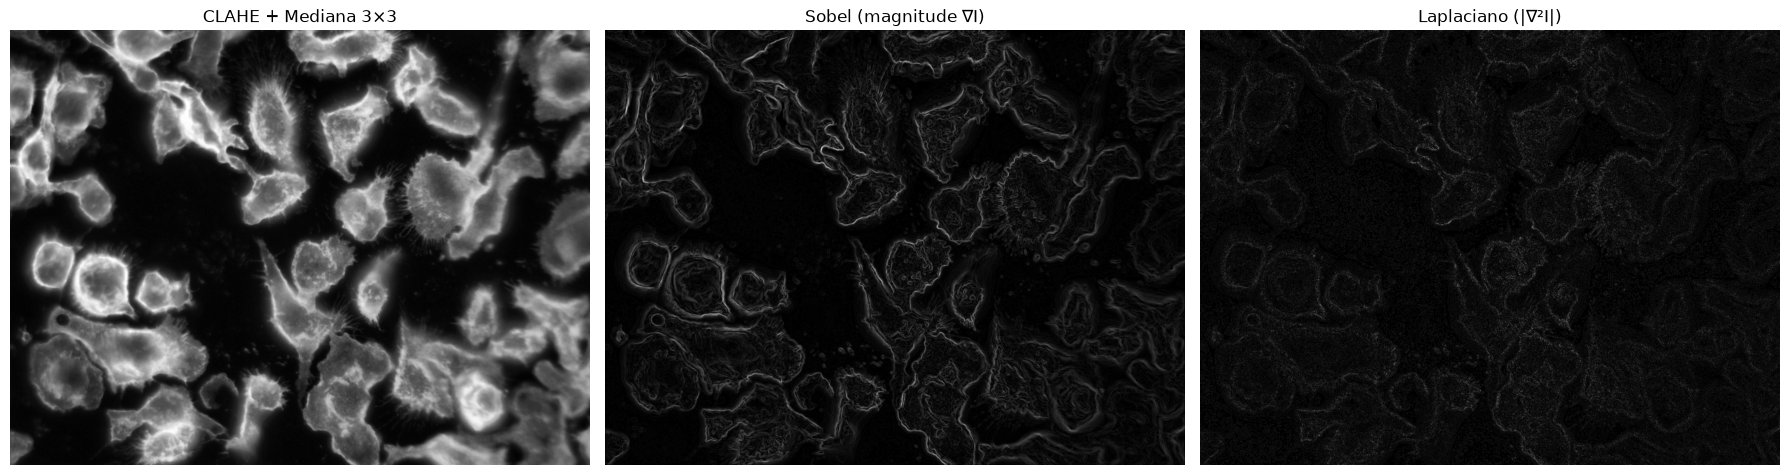

In [2]:
img_proc = _clahe(cv2.medianBlur(IMG_EX, 3))

sobel_ex = _sobel(img_proc)
lap_ex   = _laplaciano(img_proc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (img, cmap, t) in zip(axes, [
    (img_proc, 'gray', "CLAHE + Mediana 3×3"),
    (sobel_ex, 'gray', "Sobel (magnitude ∇I)"),
    (lap_ex,   'gray', "Laplaciano (|∇²I|)"),
]):
    ax.imshow(img, cmap=cmap); ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.show()

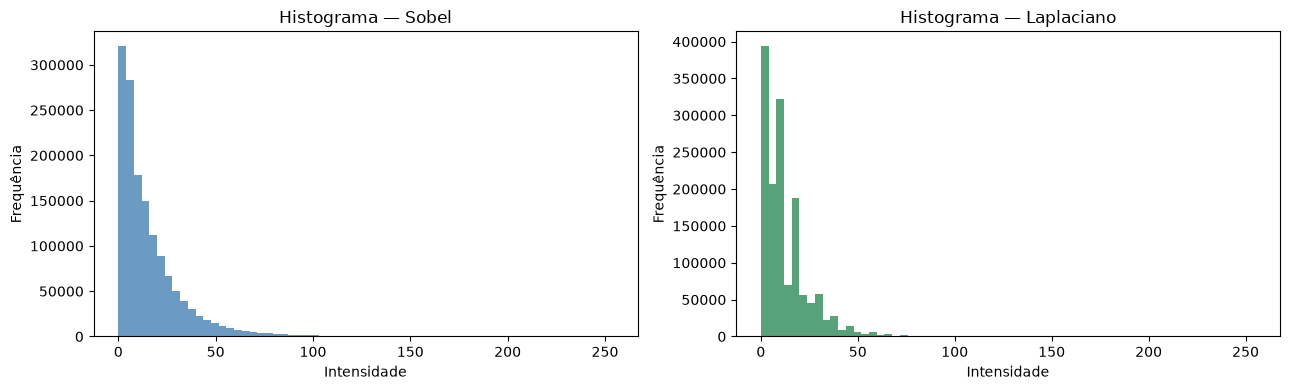

In [3]:
# Análise quantitativa dos mapas de borda
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (img, t, cor) in zip(axes, [
    (sobel_ex, "Sobel",      'steelblue'),
    (lap_ex,   "Laplaciano", 'seagreen'),
]):
    ax.hist(img.ravel(), bins=64, color=cor, alpha=0.8, edgecolor='none')
    ax.set_title(f"Histograma — {t}")
    ax.set_xlabel("Intensidade")
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

## 3. Segmentação via Watershed — Etapas Intermediárias

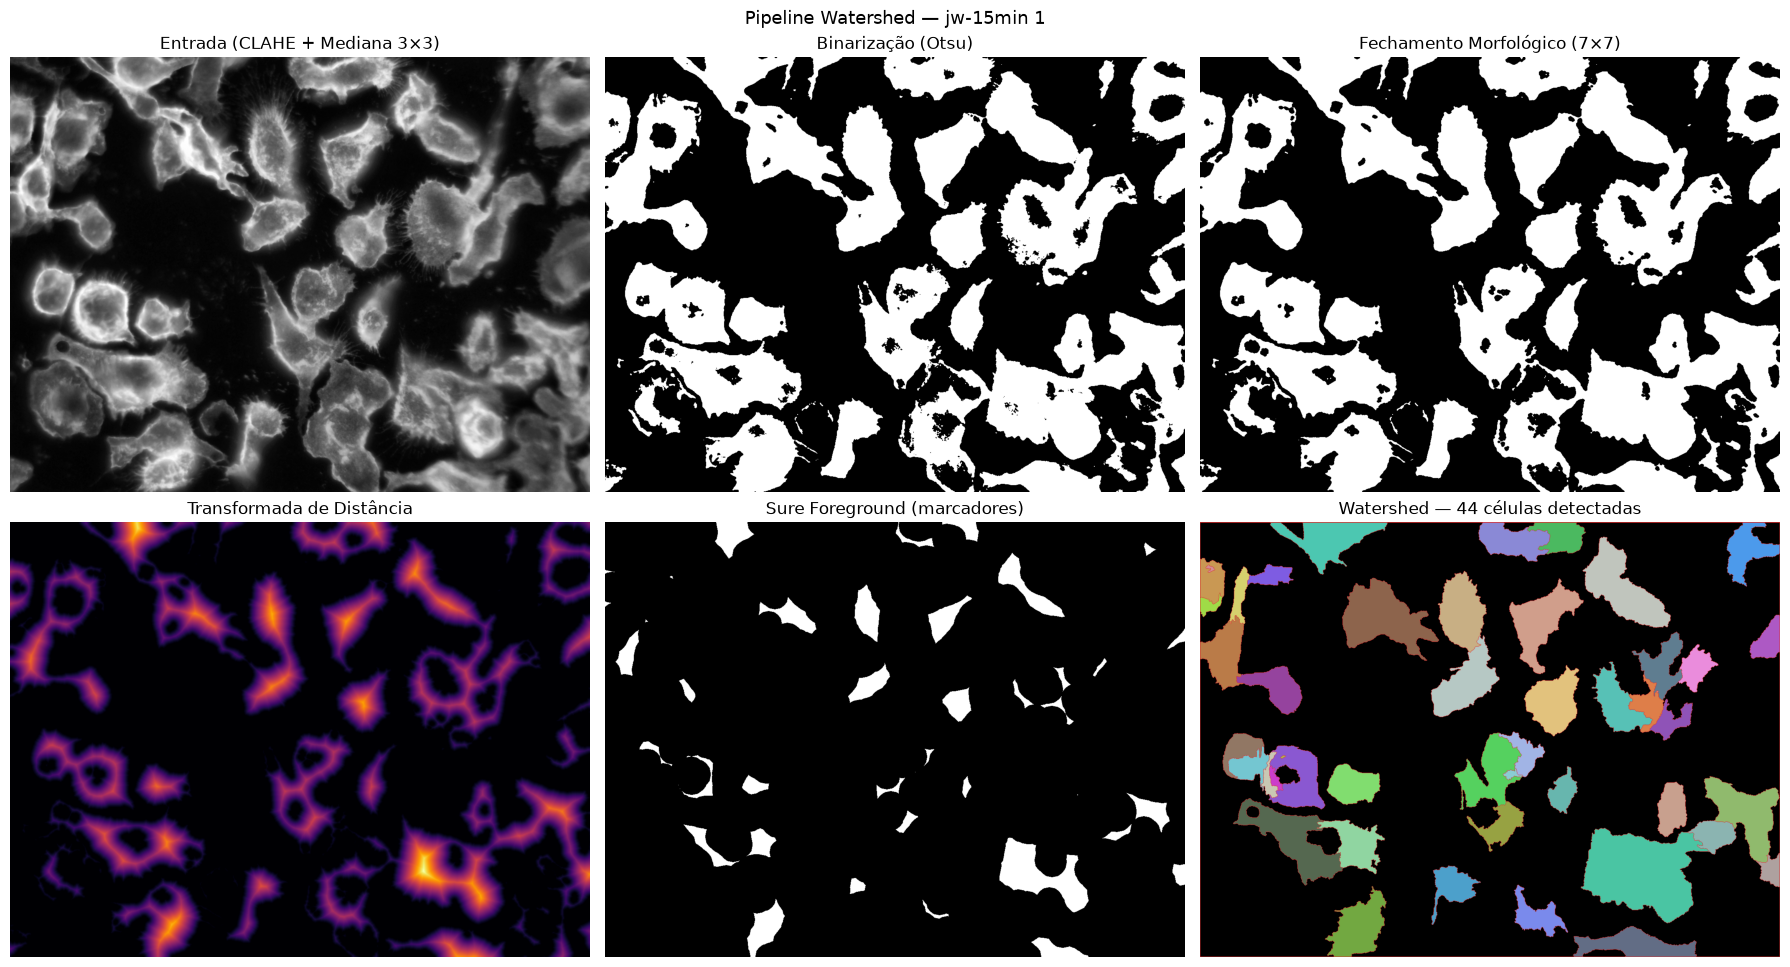

In [4]:
# Reusa img_proc da seção anterior
_, binary_otsu = cv2.threshold(img_proc, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
k              = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
binary_closed  = cv2.morphologyEx(binary_otsu, cv2.MORPH_CLOSE, k)
sure_bg        = cv2.dilate(binary_closed, k, iterations=3)
dist           = cv2.distanceTransform(binary_closed, cv2.DIST_L2, 5)
_, sure_fg_raw = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
sure_fg        = sure_fg_raw.astype(np.uint8)

markers_ex, n_ex = _watershed(img_proc)
vis_ex           = _colorir_watershed(markers_ex)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (img, cmap, t) in zip(axes.ravel(), [
    (img_proc,      'gray',    "Entrada (CLAHE + Mediana 3×3)"),
    (binary_otsu,   'gray',    "Binarização (Otsu)"),
    (binary_closed, 'gray',    "Fechamento Morfológico (7×7)"),
    (dist,          'inferno', "Transformada de Distância"),
    (sure_fg,       'gray',    "Sure Foreground (marcadores)"),
    (vis_ex,        None,      f"Watershed — {n_ex} células detectadas"),
]):
    ax.imshow(img, cmap=cmap); ax.set_title(t); ax.axis('off')

plt.suptitle(f"Pipeline Watershed — {ID_EX}", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Contagem e Validação

In [5]:
gt_n   = _gt_count(ID_EX)
gt_bin = _gt_binary(ID_EX)
pred_bin = (markers_ex > 1).astype(np.uint8)

inter = np.logical_and(pred_bin, gt_bin).sum()
union = np.logical_or(pred_bin, gt_bin).sum()
iou   = inter / union if union > 0 else 0.0

erro_abs  = abs(n_ex - gt_n)
erro_perc = erro_abs / gt_n * 100 if gt_n > 0 else float('nan')

print(f"=== Validação — {ID_EX} ===")
print(f"Detectadas  : {n_ex}")
print(f"Gabarito    : {gt_n}")
print(f"Erro abs.   : {erro_abs}")
print(f"Erro rel.   : {erro_perc:.1f}%")
print(f"IoU binária : {iou:.4f}")

=== Validação — jw-15min 1 ===
Detectadas  : 44
Gabarito    : 29
Erro abs.   : 15
Erro rel.   : 51.7%
IoU binária : 0.5315


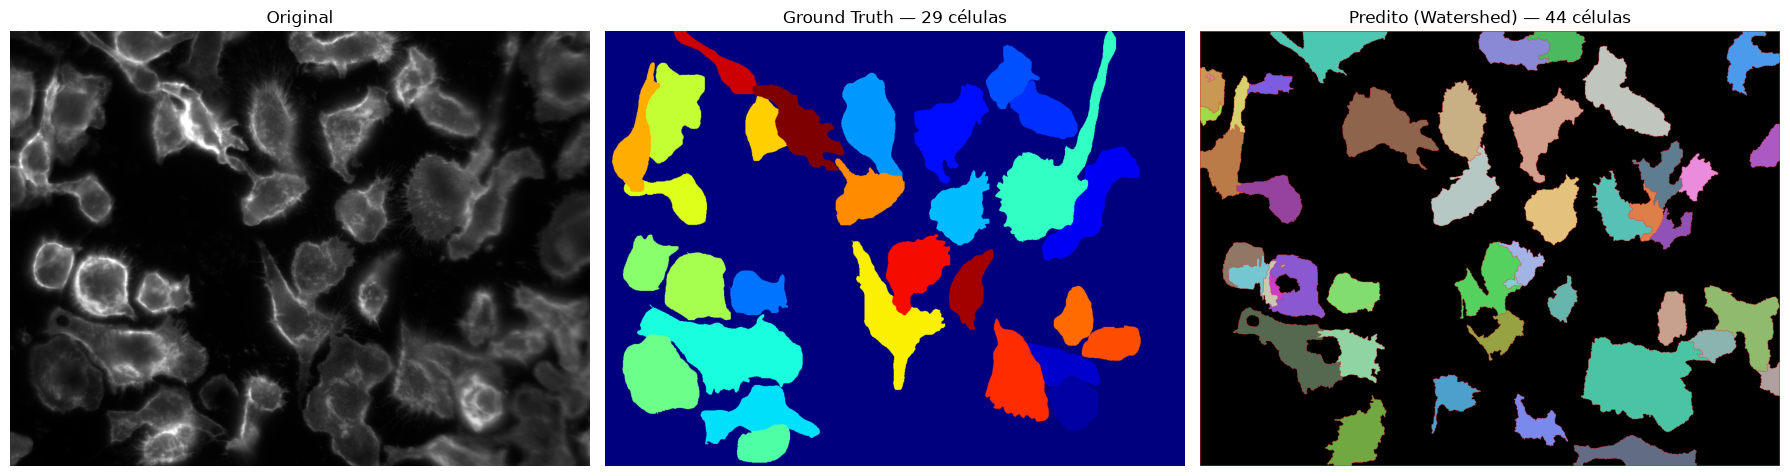

In [6]:
gt_labeled = np.load(str(PATH_GT_CELLS / f"{ID_EX}_gt_cells.npy"))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (img, cmap, t) in zip(axes, [
    (IMG_EX,    'gray', "Original"),
    (gt_labeled, 'jet', f"Ground Truth — {gt_n} células"),
    (vis_ex,     None,  f"Predito (Watershed) — {n_ex} células"),
]):
    ax.imshow(img, cmap=cmap); ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Análise Comparativa de Pipelines

In [7]:
PIPELINES = {
    "Mediana 3×3":  lambda img: _watershed(_clahe(cv2.medianBlur(img, 3))),
    "Gaussiano 5×5": lambda img: _watershed(_clahe(cv2.GaussianBlur(img, (5, 5), 0))),
    "FFT LP (r=50)": lambda img: _watershed(_clahe(_fft_lp(img, raio=50))),
}

registros = []
for img_id in ids_com_gt:
    img    = dict_imgs[img_id]
    gt_n_i = _gt_count(img_id)
    gt_b_i = _gt_binary(img_id)
    for nome, fn in PIPELINES.items():
        markers_i, n_det = fn(img)
        pred_b_i  = (markers_i > 1).astype(np.uint8)
        inter_i   = np.logical_and(pred_b_i, gt_b_i).sum()
        union_i   = np.logical_or(pred_b_i, gt_b_i).sum()
        registros.append({
            "Pipeline":   nome,
            "Imagem":     img_id,
            "GT":         gt_n_i,
            "Detectadas": n_det,
            "Erro Abs":   abs(n_det - gt_n_i),
            "Erro %":     abs(n_det - gt_n_i) / gt_n_i * 100 if gt_n_i > 0 else np.nan,
            "IoU":        inter_i / union_i if union_i > 0 else 0.0,
        })

df_raw = pd.DataFrame(registros)
df_summary = (df_raw.groupby("Pipeline")
                    .agg({"GT": "mean", "Detectadas": "mean",
                          "Erro Abs": "mean", "Erro %": "mean", "IoU": "mean"})
                    .round(2)
                    .sort_values("Erro %"))

print("=== Resumo Comparativo (média sobre imagens com GT) ===")
print(df_summary.to_string())

=== Resumo Comparativo (média sobre imagens com GT) ===
                  GT  Detectadas  Erro Abs  Erro %   IoU
Pipeline                                                
Gaussiano 5×5  25.85       30.35       7.5   32.11  0.38
FFT LP (r=50)  25.85       30.75       8.4   34.17  0.40
Mediana 3×3    25.85       30.25       8.8   36.15  0.38


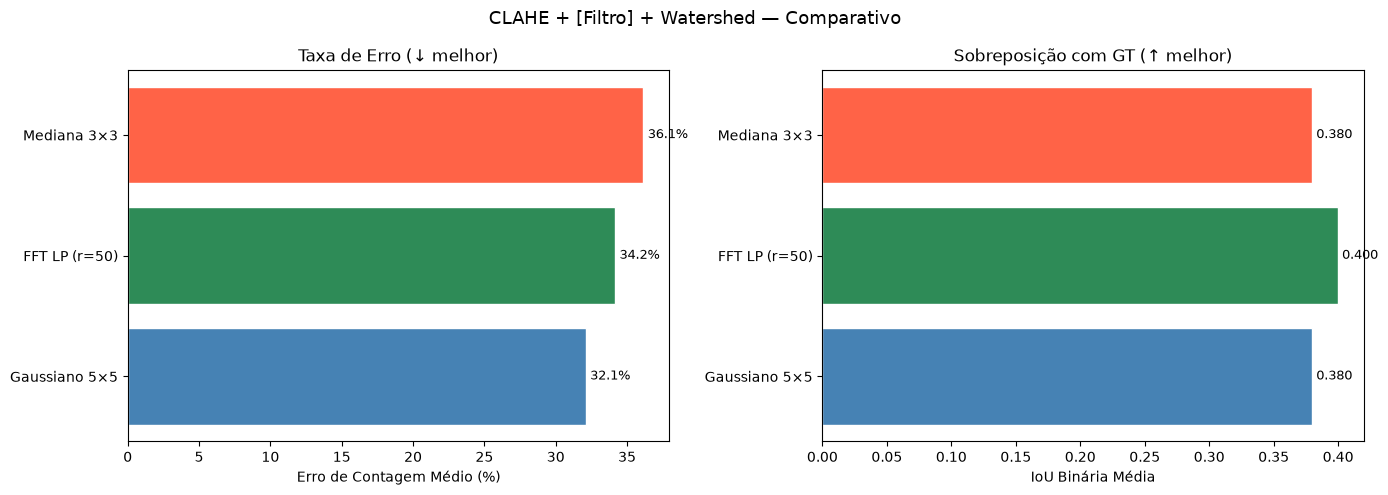

In [8]:
# Gráfico: Erro% e IoU por pipeline
cores = ['steelblue', 'seagreen', 'tomato']
nomes = list(df_summary.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(nomes, df_summary["Erro %"], color=cores, edgecolor='white')
axes[0].set_xlabel("Erro de Contagem Médio (%)")
axes[0].set_title("Taxa de Erro (↓ melhor)")
for i, v in enumerate(df_summary["Erro %"]):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=9)

axes[1].barh(nomes, df_summary["IoU"], color=cores, edgecolor='white')
axes[1].set_xlabel("IoU Binária Média")
axes[1].set_title("Sobreposição com GT (↑ melhor)")
for i, v in enumerate(df_summary["IoU"]):
    axes[1].text(v + 0.003, i, f"{v:.3f}", va='center', fontsize=9)

plt.suptitle("CLAHE + [Filtro] + Watershed — Comparativo", fontsize=13)
plt.tight_layout()
plt.show()

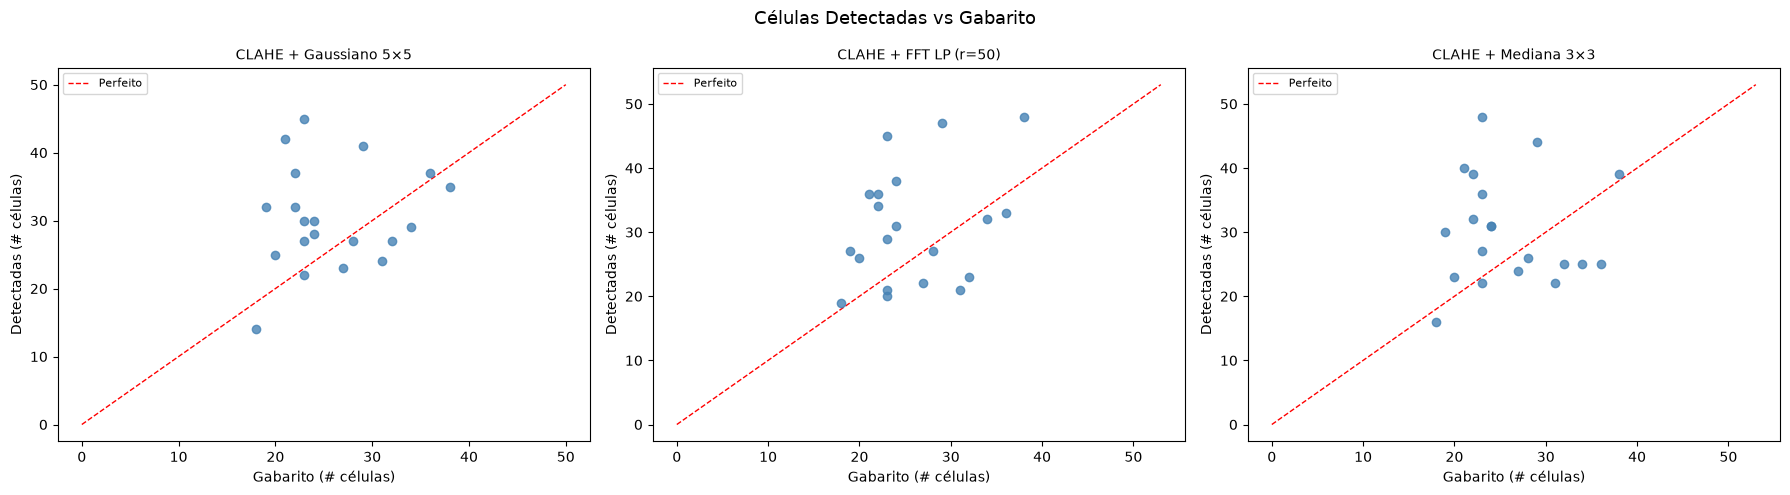

In [9]:
# Scatter: detectadas vs gabarito por pipeline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nome in zip(axes, df_summary.index):
    grupo   = df_raw[df_raw["Pipeline"] == nome]
    max_val = max(grupo["GT"].max(), grupo["Detectadas"].max()) + 5
    ax.scatter(grupo["GT"], grupo["Detectadas"], alpha=0.8, color='steelblue', zorder=3)
    ax.plot([0, max_val], [0, max_val], 'r--', lw=1, label="Perfeito")
    ax.set_xlabel("Gabarito (# células)")
    ax.set_ylabel("Detectadas (# células)")
    ax.set_title(f"CLAHE + {nome}", fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Células Detectadas vs Gabarito", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Conclusão
melhor = df_summary["Erro %"].idxmin()
pior   = df_summary["Erro %"].idxmax()

print("=== Conclusão ===")
print(f"Melhor pipeline : CLAHE + {melhor}")
print(f"  Erro médio    : {df_summary.loc[melhor, 'Erro %']:.2f}%")
print(f"  IoU médio     : {df_summary.loc[melhor, 'IoU']:.4f}")
print(f"  Detectadas μ  : {df_summary.loc[melhor, 'Detectadas']:.1f}  |  GT μ: {df_summary.loc[melhor, 'GT']:.1f}")
print()
print(f"Pior pipeline   : CLAHE + {pior}")
print(f"  Erro médio    : {df_summary.loc[pior, 'Erro %']:.2f}%")
print(f"  IoU médio     : {df_summary.loc[pior, 'IoU']:.4f}")

=== Conclusão ===
Melhor pipeline : CLAHE + Gaussiano 5×5
  Erro médio    : 32.11%
  IoU médio     : 0.3800
  Detectadas μ  : 30.4  |  GT μ: 25.9

Pior pipeline   : CLAHE + Mediana 3×3
  Erro médio    : 36.15%
  IoU médio     : 0.3800
